# Matrícula SIES 2025 — exploración y validación

Base de matrícula en educación superior chilena, corte 15-07-2025, publicada por el Servicio de
Información de Educación Superior (SIES) del Mineduc.

Este notebook hace dos cosas:

1. **Explorar la base**: qué contiene, cómo está construida y dónde están sus trampas.
2. **Validar el sitio**: reproducir en pandas los cálculos que `assets/app.js` hace en JavaScript,
   y comprobar que dan lo mismo.

La segunda parte importa porque el sitio calcula participaciones de mercado en el navegador, con
código escrito a mano. Si esos números van a sostener una decisión, alguien tiene que verificarlos
con otra herramienta y otro camino.

**Grano de la base:** una fila = una carrera única en una sede, jornada y modalidad. No es dato de
estudiante individual.

Repositorio: [github.com/juandiazr513/matricula-2025](https://github.com/juandiazr513/matricula-2025)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 60)

FOCO  = '#1f3fa8'   # misma paleta del sitio
GRIS  = '#b9bfc7'
OCRE  = '#a9550b'
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 9, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': .25, 'grid.linewidth': .6, 'axes.axisbelow': True,
})

## Parte 1 — La base

### 1.1 Carga y estructura

In [2]:
# El notebook corre tanto desde notebooks/ como desde la raíz del repo.
CANDIDATOS = [Path('data/matricula2025.csv'), Path('../data/matricula2025.csv')]
RUTA = next((p for p in CANDIDATOS if p.exists()), None)
if RUTA is None:
    raise FileNotFoundError('No se encontró data/matricula2025.csv. Corre el notebook desde el repo.')

df = pd.read_csv(RUTA)
print(f'Ruta   : {RUTA}')
print(f'Filas  : {len(df):,}')
print(f'Columnas: {df.shape[1]}')

Ruta   : ../data/matricula2025.csv
Filas  : 16,089
Columnas: 48


La base limpia sale de `etl/prep.py`, que toma el archivo original del SIES —ISO-8859-1, separador
`;`, decimales con coma— y lo normaliza a UTF-8 y snake_case. El original no está en el repo por
peso; se baja de
[datosabiertos.mineduc.cl](https://datosabiertos.mineduc.cl/matricula-en-educacion-superior/).

In [3]:
info = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'nulos': df.isna().sum(),
    'únicos': df.nunique(),
})
info

,tipo,nulos,únicos
mat_total,int64,0,794
mat_muj,int64,0,560
mat_hom,int64,0,501
mat_nb,int64,0,2
mat1_total,float64,5364,324
mat1_muj,float64,5979,222
mat1_hom,float64,6117,208
mat1_nb,float64,16083,1
tipo_inst,str,0,3
inst_n2,str,0,5


In [4]:
# Grano: ¿es cod_carrera la llave?
print('cod_carrera es única  :', df.cod_carrera.is_unique)
print('instituciones         :', df.institucion.nunique())
print('sedes                 :', df.sede.nunique())
print('nombres de carrera    :', df.carrera.nunique())
print('áreas genéricas       :', df.area_generica.nunique())
print('comunas               :', df.comuna.nunique())

cod_carrera es única  : True
instituciones         : 122
sedes                 : 193
nombres de carrera    : 5608
áreas genéricas       : 284
comunas               : 104


#### Un corte, no una serie

Antes de cualquier idea de tendencia, conviene mirar esto:

In [5]:
print(df.filter(like='anio').columns.tolist() or 'sin columna de año en la base limpia')
print()
print('Matrícula total del corte:', f'{df.mat_total.sum():,}')

sin columna de año en la base limpia

Matrícula total del corte: 1,455,639


El archivo original trae una columna `AÑO` con el valor `MAT_2025` en las 16.089 filas. `prep.py`
la descarta por constante. **La base es un corte único: no permite medir crecimiento.** Cualquier
serie de tiempo exige bajar los archivos de años anteriores.

### 1.2 Integridad

Cuatro condiciones que la base debe cumplir si está bien formada. Si alguna falla, hay un problema
de lectura antes que de análisis.

In [6]:
sexo = (df.mat_muj + df.mat_hom + df.mat_nb - df.mat_total).abs().sum()
cols_edad = ['e15_19','e20_24','e25_29','e30_34','e35_39','e40_mas','e_sin_info']
edad = (df[cols_edad].sum(axis=1) - df.mat_total).abs().sum()
mat1_gt = (df.mat1_total > df.mat_total).sum()

checks = pd.DataFrame([
    ('Suma por sexo = matrícula total',        f'desviación {sexo}',   sexo == 0),
    ('Suma de rangos etarios = matrícula total', f'desviación {edad}', edad == 0),
    ('Primer año ≤ matrícula total',           f'{mat1_gt} violaciones', mat1_gt == 0),
    ('cod_carrera única',                      f'{len(df):,} filas',   df.cod_carrera.is_unique),
], columns=['chequeo', 'resultado', 'pasa'])
checks

,chequeo,resultado,pasa
0,Suma por sexo = matrícula total,desviación 0,True
1,Suma de rangos etarios = matrícula total,desviación 0,True
2,Primer año ≤ matrícula total,0 violaciones,True
3,cod_carrera única,"16,089 filas",True


#### Contraste con la fuente oficial

El informe *Matrícula en Educación Superior en Chile 2025* del SIES reporta 1.455.639 matriculados
para el sistema completo. Si la lectura del archivo fuera incorrecta, esta suma no calzaría.

In [7]:
OFICIAL = 1_455_639
print(f'Base    : {df.mat_total.sum():,}')
print(f'Informe : {OFICIAL:,}')
print('Calza   :', df.mat_total.sum() == OFICIAL)

Base    : 1,455,639
Informe : 1,455,639
Calza   : True


### 1.3 La trampa de los nulos

Acá está el error que uno comete al leer esta base por primera vez: asumir que un vacío en un
conteo significa cero.

In [8]:
print('Columna mat1_total (matrícula de primer año)')
print('  ceros explícitos :', (df.mat1_total == 0).sum())
print('  vacíos           :', df.mat1_total.isna().sum())
print('  con dato         :', df.mat1_total.notna().sum())

Columna mat1_total (matrícula de primer año)
  ceros explícitos : 0
  vacíos           : 5364
  con dato         : 10725


**El SIES no escribe ni un solo cero en esa columna.** Escribe vacío. Eso significa que el vacío
carga dos significados distintos y hay que separarlos antes de rellenar nada.

In [9]:
por_plan = df.groupby('tipo_plan').agg(
    filas=('cod_carrera', 'count'),
    reportan_1er=('reporta_mat1', 'sum'),
    matricula=('mat_total', 'sum'),
)
por_plan['%_reporta'] = (por_plan.reportan_1er / por_plan.filas * 100).round(1)
por_plan

,filas,reportan_1er,matricula,%_reporta
tipo_plan,,,,
Plan Especial,545,294,23622,53.9
Plan Regular,14723,10431,1366324,70.8
Plan Regular de Continuidad,821,0,65693,0.0


Ahí está la distinción:

- **Plan Regular y Plan Especial**: parte reporta y parte no. El vacío ahí es plausiblemente una
  carrera que no abrió admisión este año. Un cero razonable.
- **Plan Regular de Continuidad**: 821 filas, ninguna reporta, y sin embargo acumulan 65.693
  matriculados. Un programa de prosecución con 65 mil alumnos y cero admitidos es imposible. El
  vacío ahí es **"no se pide el dato"**, no "no admitió".

Rellenar con cero mezcla las dos cosas y hace desaparecer 65.693 estudiantes de cualquier análisis
de admisión. Por eso `prep.py` deja `mat1_*` como nulo y agrega la columna `reporta_mat1`.

Consecuencia práctica: **el crecimiento de los planes de continuidad no se puede medir por primer
año, ni con esta base ni con las de años anteriores.** Para esos hay que usar matrícula total.

### 1.4 Cómo se reparte el sistema

In [10]:
inst = df.groupby('tipo_inst').agg(
    instituciones=('institucion', 'nunique'),
    carreras=('cod_carrera', 'count'),
    matricula=('mat_total', 'sum'),
)
inst['%'] = (inst.matricula / inst.matricula.sum() * 100).round(1)
inst.sort_values('matricula', ascending=False)

,instituciones,carreras,matricula,%
tipo_inst,,,,
Universidades,55,8888,859040,59.0
Institutos Profesionales,28,4955,444054,30.5
Centros de Formación Técnica,39,2246,152545,10.5


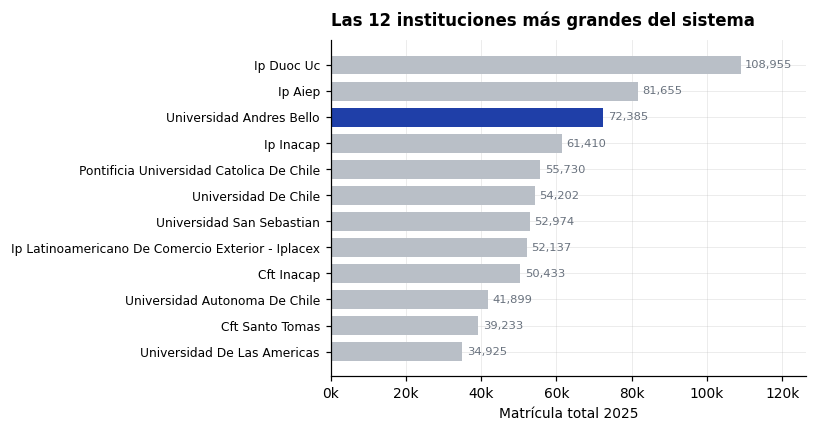

In [11]:
top = df.groupby('institucion').mat_total.sum().sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(7.5, 4))
colores = [FOCO if 'ANDRES BELLO' in i else GRIS for i in top.index]
ax.barh(range(len(top)), top.values, color=colores, height=.72)
ax.set_yticks(range(len(top)), [i.title() for i in top.index], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Matrícula total 2025')
ax.set_title('Las 12 instituciones más grandes del sistema', loc='left', fontweight='bold', pad=10)
ax.xaxis.set_major_formatter(lambda x, p: f'{int(x/1000)}k')
for i, v in enumerate(top.values):
    ax.text(v + 1200, i, f'{v:,}', va='center', fontsize=7.5, color='#69727e')
ax.set_xlim(0, top.max() * 1.16)
plt.tight_layout(); plt.show()

UNAB es la universidad más grande del país por matrícula y la tercera institución, detrás de dos
institutos profesionales.

In [12]:
pre = df[df.nivel_global == 'Pregrado']

tabla = pre.pivot_table(index='modalidad', columns='tipo_plan', values='mat_total',
                        aggfunc='sum', fill_value=0)
tabla['TOTAL'] = tabla.sum(axis=1)
tabla.loc['TOTAL'] = tabla.sum()
tabla

tipo_plan,Plan Especial,Plan Regular,Plan Regular de Continuidad,TOTAL
modalidad,,,,
No Presencial,8533,141718,33298,183549
Presencial,9037,1086058,28091,1123186
Semipresencial,809,15650,4150,20609
TOTAL,18379,1243426,65539,1327344


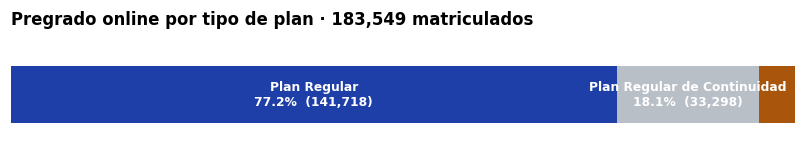

In [13]:
onl = pre[pre.modalidad == 'No Presencial']
mix = onl.groupby('tipo_plan').mat_total.sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7.5, 1.5))
izq = 0
cols = [FOCO, GRIS, OCRE]
for (nombre, val), c in zip(mix.items(), cols):
    ax.barh(0, val, left=izq, color=c, height=.55)
    pctv = val / mix.sum() * 100
    if pctv > 5:
        ax.text(izq + val/2, 0, f'{nombre}\n{pctv:.1f}%  ({val:,})', ha='center', va='center',
                color='white', fontsize=8, fontweight='bold')
    izq += val
ax.set_xlim(0, mix.sum()); ax.set_ylim(-.5, .5)
ax.axis('off')
ax.set_title(f'Pregrado online por tipo de plan · {mix.sum():,} matriculados',
             loc='left', fontweight='bold', pad=12)
plt.tight_layout(); plt.show()

Ese 18,1% de continuidad es exactamente el pedazo del pregrado online que no reporta primer año.
No es un caso de borde.

In [14]:
areas = pre.groupby('area').agg(carreras=('cod_carrera','count'), matricula=('mat_total','sum'))
areas['%'] = (areas.matricula / areas.matricula.sum() * 100).round(1)
areas.sort_values('matricula', ascending=False)

,carreras,matricula,%
area,,,
Tecnología,3918,369747,27.9
Salud,1333,244671,18.4
Administración y Comercio,2641,243287,18.3
Ciencias Sociales,1035,146192,11.0
Educación,1290,119037,9.0
Arte y Arquitectura,690,74082,5.6
Derecho,224,52713,4.0
Agropecuaria,262,44431,3.3
Ciencias Básicas,240,24567,1.9


### 1.5 Perfil de la matrícula

In [15]:
perfil = pd.DataFrame({
    'mujeres_%':  [df.mat_muj.sum() / df.mat_total.sum() * 100],
    'hombres_%':  [df.mat_hom.sum() / df.mat_total.sum() * 100],
    'no_binarios': [df.mat_nb.sum()],
    'nb_filas_con_dato': [(df.mat_nb > 0).sum()],
}).round(1)
perfil

,mujeres_%,hombres_%,no_binarios,nb_filas_con_dato
0,53.3,46.7,27,27


No binarios tiene dato en 27 de 16.089 filas. No admite desagregación: cualquier corte por esa
variable produce celdas de uno o dos casos.

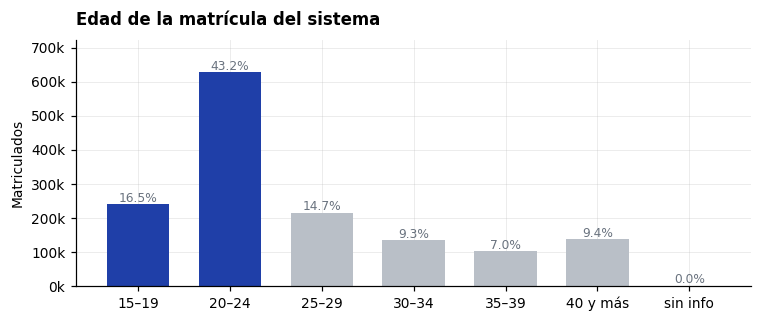

In [16]:
edades = df[cols_edad].sum()
edades.index = ['15–19','20–24','25–29','30–34','35–39','40 y más','sin info']

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(len(edades)), edades.values, color=GRIS, width=.68)
ax.bar([0, 1], edades.values[:2], color=FOCO, width=.68)
ax.set_xticks(range(len(edades)), edades.index)
ax.set_ylabel('Matriculados')
ax.yaxis.set_major_formatter(lambda x, p: f'{int(x/1000)}k')
ax.set_title('Edad de la matrícula del sistema', loc='left', fontweight='bold', pad=10)
for i, v in enumerate(edades.values):
    ax.text(i, v + 8000, f'{v/edades.sum()*100:.1f}%', ha='center', fontsize=8, color='#69727e')
ax.set_ylim(0, edades.max() * 1.15)
plt.tight_layout(); plt.show()

El 43% de la matrícula tiene 25 años o más. El sistema dejó de ser mayoritariamente joven hace
rato, y eso es justamente lo que empuja la modalidad online y las jornadas vespertinas.

In [17]:
# TES: origen escolar. Solo válido en primer año de pregrado.
tes_cols = ['tes_mun','tes_psub','tes_ppag','tes_cad','tes_slep']
tes_pre  = pre[pre.tes_total > 0]
tes = tes_pre[tes_cols].sum()
tes.index = ['Municipal','Part. subvencionado','Part. pagado','Adm. delegada','SLEP']
pd.DataFrame({'estudiantes': tes, '%': (tes/tes.sum()*100).round(1)})

,estudiantes,%
Municipal,360181,29.8
Part. subvencionado,639086,52.9
Part. pagado,134453,11.1
Adm. delegada,44336,3.7
SLEP,30020,2.5


**Advertencia:** la cobertura TES solo aplica al primer año de pregrado, y ni siquiera lo cubre
entero. Usarla en posgrado o sobre matrícula total produce lecturas falsas.

In [18]:
print('Cobertura del reporte TES sobre el primer año de pregrado:')
rep = pre[pre.reporta_mat1]
print(f'  primer año reportado : {rep.mat1_total.sum():,}')
print(f'  con dato TES         : {rep[rep.tes_total>0].tes_total.sum():,}')
print(f'  cobertura            : {rep[rep.tes_total>0].tes_total.sum()/rep.mat1_total.sum()*100:.1f}%')

Cobertura del reporte TES sobre el primer año de pregrado:
  primer año reportado : 362,669.0
  con dato TES         : 1,067,929
  cobertura            : 294.5%


### 1.6 Por qué el sitio compara por área genérica

Para preguntar "quién más dicta esta carrera" hace falta una llave que agrupe programas
equivalentes entre instituciones. El nombre de la carrera no sirve:

In [19]:
print('nombres de carrera distintos :', df.carrera.nunique())
print('áreas genéricas distintas    :', df.area_generica.nunique())
print()
ej = df[df.area_generica == 'Enfermería'].carrera.value_counts()
print(f'Bajo el área genérica "Enfermería" conviven {len(ej)} nombres distintos:')
print(ej.head(8).to_string())

nombres de carrera distintos : 5608
áreas genéricas distintas    : 284

Bajo el área genérica "Enfermería" conviven 4 nombres distintos:
carrera
ENFERMERIA                                 108
BACHILLERATO EN ENFERMERIA                   1
ENFERMERIA Y LICENCIATURA EN ENFERMERIA      1
ENFERMERIA, LICENCIATURA EN ENFERMERIA       1


Si comparáramos por nombre, "Enfermería" y "Enfermería (Vespertino)" serían mercados separados y
la comparación se desarmaría. El área genérica del SIES es la categoría diseñada exactamente para
esto.

## Parte 2 — Validación del sitio

`assets/app.js` construye mercados y calcula participaciones en JavaScript. Acá se rehace la misma
lógica en pandas, por un camino independiente, y se contrastan los resultados.

### 2.1 La lógica, traducida

Vive en [`analisis/mercados.py`](../analisis/mercados.py), fuera del notebook, para que exista una
sola implementación compartida con el resto de los notebooks.

Un mercado es la combinación de **área genérica + territorio**, y opcionalmente jornada y
modalidad. Reglas que aplica el sitio:

- filtra por universo (tipo de institución) y nivel;
- descarta las filas sin matrícula en la métrica elegida — con primer año, una carrera sin
  admitidos no compite por el estudiante de este año;
- conserva solo los mercados donde la institución en foco está presente;
- ordena las instituciones por matrícula y asigna posición y participación.

In [20]:
import sys
RAIZ = next(p for p in [Path('.'), Path('..')] if (p / 'analisis').exists())
sys.path.insert(0, str(RAIZ.resolve()))

from analisis.mercados import construir_mercados, situacion, resumen_foco, suite

# El motor vive en analisis/mercados.py y lo comparten todos los notebooks. Una sola
# implementación: cuando un criterio cambia —como pasó con el desempate y con el umbral de
# liderazgo compartido— se corrige en un lugar y no en diez copias.
import inspect
print(inspect.getsource(construir_mercados))

def construir_mercados(df, foco=UNAB, metrica='mat1_total', ambito='region',
                       universo='Universidades', nivel='Pregrado',
                       match_jornada=True, match_modalidad=False, umbral=5):
    """
    Arma los mercados donde `foco` compite y calcula posición y participación.

    Un mercado es área genérica + territorio, y opcionalmente jornada y modalidad. El área
    genérica del SIES (284 categorías) es la que agrupa programas equivalentes entre
    instituciones; el nombre de carrera no sirve porque hay 5.608 variantes.

    Parámetros que cambian la lectura, no el dato:
      ambito : 'comuna' | 'provincia' | 'region' | 'pais'
          El denominador. La misma carrera da 54,7% de participación medida por comuna y 8,9%
          medida por región. Ambas son correctas y responden preguntas distintas.
      umbral : float
          Brecha máxima, en % del máximo del mercado, para considerar el liderazgo compartido.
          Con 0 solo entran los empa

In [21]:
mk = construir_mercados(df, foco='UNIVERSIDAD ANDRES BELLO', umbral=5)
unab = mk[mk.institucion == 'UNIVERSIDAD ANDRES BELLO']

solo = ((unab.co_lider) & (~unab.compartido) & (unab.n_inst > 1)).sum()
comp = ((unab.co_lider) & (unab.compartido)).sum()
mono = (unab.n_inst == 1).sum()

print(f'Mercados donde UNAB compite : {len(unab)}')
print(f'  lidera sola               : {solo}')
print(f'  liderazgo compartido      : {comp}')
print(f'  sin competencia (única)   : {mono}')
print(f'  no lidera                 : {len(unab) - solo - comp - mono}')
print(f'Primer año UNAB             : {unab.val.sum():,}')

Mercados donde UNAB compite : 128
  lidera sola               : 25
  liderazgo compartido      : 3
  sin competencia (única)   : 15
  no lidera                 : 85
Primer año UNAB             : 11,969.0


### 2.2 Contraste contra el JavaScript

Estos son los números que produce `app.js` con la configuración por defecto —universidades,
pregrado, primer año, mercado por región, exigiendo misma jornada—, medidos ejecutando su lógica
en Node sobre el mismo CSV:

| Indicador | app.js |
|---|---|
| Mercados donde UNAB compite | 128 |
| Lidera sola | 25 |
| Liderazgo compartido | 3 |
| Sin competencia | 15 |
| Ingeniería Comercial · RM · Diurna — UNAB | 469 |
| Ingeniería Comercial · RM · Diurna — mercado | 5.265 |
| Participación | 8,9% |
| Posición | 3ª |

Si pandas da lo mismo por un camino distinto, los números del sitio se sostienen.

In [22]:
ic = mk[(mk.area_generica == 'Ingeniería Comercial') & (mk.geo == 'Metropolitana') &
        (mk.jornada == 'Diurna')].sort_values('pos')
ic[['pos','institucion','val','share']].head(6).round(1)

,pos,institucion,val,share
333,1,UNIVERSIDAD DE CHILE,660.0,12.5
334,2,UNIVERSIDAD ADOLFO IBAÑEZ,657.0,12.5
335,3,UNIVERSIDAD ANDRES BELLO,469.0,8.9
336,4,PONTIFICIA UNIVERSIDAD CATOLICA DE CHILE,456.0,8.7
337,5,UNIVERSIDAD DEL DESARROLLO,429.0,8.1
338,6,UNIVERSIDAD DIEGO PORTALES,377.0,7.2


In [23]:
u_ic = ic[ic.institucion == 'UNIVERSIDAD ANDRES BELLO'].iloc[0]

pruebas = [
    ('mercados donde compite',        len(unab),                    128),
    ('lidera sola',                   int(solo),                    25),
    ('liderazgo compartido',          int(comp),                    3),
    ('sin competencia',               int(mono),                    15),
    ('Ing. Comercial RM — UNAB',      int(u_ic.val),                469),
    ('Ing. Comercial RM — mercado',   int(u_ic.total_mercado),      5265),
    ('Ing. Comercial RM — posición',  int(u_ic.pos),                3),
    ('Ing. Comercial RM — colíderes', int(ic.co_lider.sum()),       2),
]
res = pd.DataFrame(pruebas, columns=['indicador','pandas','app.js'])
res['calza'] = res.pandas == res['app.js']
print(res.to_string(index=False))
print()
assert res.calza.all(), 'DISCREPANCIA entre pandas y app.js'
print('✓ Las dos implementaciones coinciden en todos los indicadores.')

                    indicador  pandas  app.js  calza
       mercados donde compite     128     128   True
                  lidera sola      25      25   True
         liderazgo compartido       3       3   True
              sin competencia      15      15   True
     Ing. Comercial RM — UNAB     469     469   True
  Ing. Comercial RM — mercado    5265    5265   True
 Ing. Comercial RM — posición       3       3   True
Ing. Comercial RM — colíderes       2       2   True

✓ Las dos implementaciones coinciden en todos los indicadores.


In [24]:
# La participación redondeada y la suma de segmentos
print(f'Participación UNAB en Ing. Comercial RM Diurna: {u_ic.share:.1f}%  (app.js: 8,9%)')

suma = ic.val.sum()
print(f'Suma de los segmentos del mercado: {suma:,} = total {int(u_ic.total_mercado):,} →',
      suma == u_ic.total_mercado)

Participación UNAB en Ing. Comercial RM Diurna: 8.9%  (app.js: 8,9%)
Suma de los segmentos del mercado: 5,265.0 = total 5,265 → True


### 2.3 Lo que apareció al validar

La primera corrida **no pasó**: pandas contaba 42 liderazgos y `app.js` contaba 41. Tirando de ese
hilo aparecieron tres problemas, y el de la diferencia era el menos grave.

#### Problema 1 — el desempate dependía del orden del archivo

In [25]:
d = df[(df.tipo_inst=='Universidades') & (df.nivel_global=='Pregrado')]
d = d[d.mat1_total.notna() & (d.mat1_total > 0)]
g = d.groupby(['area_generica','region','jornada','institucion'], observed=True).mat1_total.sum().reset_index()

pres = g[g.institucion=='UNIVERSIDAD ANDRES BELLO'][['area_generica','region','jornada']]
g = g.merge(pres, on=['area_generica','region','jornada'])

mx  = g.groupby(['area_generica','region','jornada'], observed=True).mat1_total.transform('max')
top = g[g.mat1_total == mx]
emp = top.groupby(['area_generica','region','jornada'], observed=True).size()
emp = emp[emp > 1]

for k in emp.index:
    sub = top[(top.area_generica==k[0]) & (top.region==k[1]) & (top.jornada==k[2])]
    print(' · '.join(k))
    print(sub[['institucion','mat1_total']].to_string(index=False))

Administración de Empresas e Ing. Asociadas · Metropolitana · Vespertina
               institucion  mat1_total
  UNIVERSIDAD ANDRES BELLO        32.0
UNIVERSIDAD DIEGO PORTALES        32.0


**UNAB y la Universidad Diego Portales tienen exactamente 32 matriculados de primer año.** Empate
perfecto. Ninguna implementación estaba mala: pandas, con `rank(method='first')` sobre un `groupby`
que ordena alfabéticamente, coronaba a *Andrés Bello*; JavaScript, con un sort estable, respetaba
el orden de las filas del CSV, donde venía primero *Diego Portales*.

El liderazgo dependía del orden del archivo. Un criterio que nadie declara y que cambia con cada
corte del SIES. Se arregló con desempate alfabético explícito en ambos lados.

#### Problema 2 — el primer lugar podía ser una foto finish

Si dos instituciones separadas por 0 alumnos empatan, ¿qué pasa con dos separadas por 3?

In [26]:
g2 = g.sort_values(['area_generica','region','jornada','mat1_total'], ascending=[1,1,1,0])
K = ['area_generica','region','jornada']
dos = g2.groupby(K, observed=True).head(2)
br = dos.groupby(K, observed=True).agg(lider=('mat1_total','max'), segundo=('mat1_total','min'),
                                       n=('institucion','size')).reset_index()
br = br[br.n > 1]
br['brecha']     = br.lider - br.segundo
br['brecha_rel'] = (br.lider - br.segundo) / br.lider * 100

print(f'Mercados de UNAB con competencia real: {len(br)}')
print()
print('Brecha entre 1º y 2º — distribución:')
print(br[['brecha','brecha_rel']].describe(percentiles=[.05,.25,.5]).round(1).to_string())
print()
print('Los 6 mercados más apretados:')
print(br.nsmallest(6,'brecha_rel')[K+['lider','segundo','brecha','brecha_rel']].round(1).to_string(index=False))

Mercados de UNAB con competencia real: 113

Brecha entre 1º y 2º — distribución:
       brecha  brecha_rel
count   113.0       113.0
mean     44.7        26.2
std      57.1        19.6
min       0.0         0.0
5%        3.0         3.1
25%      12.0         9.8
50%      24.0        21.1
max     461.0        93.9

Los 6 mercados más apretados:
                              area_generica        region    jornada  lider  segundo  brecha  brecha_rel
Administración de Empresas e Ing. Asociadas Metropolitana Vespertina   32.0     32.0     0.0         0.0
                       Ingeniería Comercial Metropolitana     Diurna  660.0    657.0     3.0         0.5
                                 Periodismo Metropolitana     Diurna  144.0    143.0     1.0         0.7
                 Obstetricia y Puericultura    Valparaíso     Diurna  117.0    116.0     1.0         0.9
                       Ingeniería Comercial Metropolitana Vespertina   75.0     73.0     2.0         2.7
                Ingenier

Ahí está el caso que veníamos citando sin mirarlo: **Ingeniería Comercial, RM, diurno. La
Universidad de Chile tiene 660 y la Adolfo Ibáñez 657.** Tres alumnos de diferencia en un mercado
de 5.265. Lo habíamos estado reportando como "líder: U. de Chile", como si fuera una ventaja.

#### Problema 3 — liderar un mercado de uno no es liderar

In [27]:
u_tmp = mk[mk.institucion == 'UNIVERSIDAD ANDRES BELLO']
print(f'De los mercados donde UNAB "aparecía primera" con el criterio viejo:')
print(f'  con al menos un competidor : {(u_tmp.n_inst > 1).sum()}')
print(f'  donde es la única oferente : {(u_tmp.n_inst == 1).sum()}')
print()
print('Ejemplos de mercados sin competencia:')
print(u_tmp[u_tmp.n_inst==1].nlargest(5,'val')[['area_generica','geo','jornada','val']].to_string(index=False))

De los mercados donde UNAB "aparecía primera" con el criterio viejo:


  con al menos un competidor : 113
  donde es la única oferente : 15

Ejemplos de mercados sin competencia:
                                          area_generica           geo jornada   val
                 Bachillerato y/o Licenciatura en Salud    Valparaíso  Diurna 163.0
                 Ingeniería Marina y Marítimo Portuaria    Valparaíso  Diurna 103.0
Ingeniería en Automatización, Instrumentación y Control Metropolitana  Diurna  67.0
                                               Geología    Valparaíso  Diurna  63.0
                 Ingeniería Marina y Marítimo Portuaria        Biobío  Diurna  54.0


**15 de los 42 "liderazgos" eran mercados donde UNAB es la única universidad que dicta esa carrera
en esa región y jornada.** Ser el único no es ganar. El contador viejo mezclaba monopolios locales
con victorias competitivas y las presentaba como lo mismo.

### 2.4 El umbral, y por qué es una convención

Para separar liderazgo real de foto finish hace falta un corte. Este es el efecto de cada opción:

In [28]:
filas = []
for u in [0, 2, 5, 10]:
    m = construir_mercados(df, foco='UNIVERSIDAD ANDRES BELLO', umbral=u)
    x = m[m.institucion == 'UNIVERSIDAD ANDRES BELLO']
    s_ = ((x.co_lider) & (~x.compartido) & (x.n_inst > 1)).sum()
    c_ = ((x.co_lider) & (x.compartido)).sum()
    afect = br[br.brecha_rel <= u]
    filas.append({'umbral_%': u, 'lidera_sola': int(s_), 'compartido': int(c_),
                  'sin_competencia': int((x.n_inst == 1).sum()),
                  'mercados_bajo_umbral': len(afect),
                  'brecha_máx_alumnos': int(afect.brecha.max()) if len(afect) else 0})
pd.DataFrame(filas)

,umbral_%,lidera_sola,compartido,sin_competencia,mercados_bajo_umbral,brecha_máx_alumnos
0,0,26,1,15,1,0
1,2,26,1,15,4,3
2,5,25,3,15,13,6
3,10,20,12,15,29,23


El sitio usa **5%** por defecto: cubre 13 de los 113 mercados con competencia, y la brecha más
grande que declara empatada es de 6 alumnos. Con 10% ya estaría llamando empate a diferencias de
23 alumnos, que es demasiado.

Ahora, lo importante y lo que hay que decir en cualquier informe: **este umbral es una convención
de materialidad, no una prueba estadística.** La base es un censo, no una muestra: no hay error
muestral que invocar, no hay intervalo de confianza que calcular. La pregunta real es otra —¿cuánto
se mueve esta cifra de un año a otro?— y esa solo se responde con la serie histórica, que esta base
no trae.

Hasta entonces, el 5% es un juicio defendible y explícito. Lo importante no es que sea el número
correcto, sino que esté declarado y se pueda mover.

### 2.5 Cómo queda el conteo honesto

In [29]:
resumen = pd.DataFrame([
    ('Lidera sola (con competencia)', int(solo)),
    ('Liderazgo compartido (≤5%)',    int(comp)),
    ('Sin competencia (única oferente)', int(mono)),
    ('No lidera',                     int(len(unab) - solo - comp - mono)),
], columns=['situación', 'mercados'])
resumen['%'] = (resumen.mercados / len(unab) * 100).round(1)
print(resumen.to_string(index=False))
print()
print(f'Total: {resumen.mercados.sum()} mercados')

                       situación  mercados    %
   Lidera sola (con competencia)        25 19.5
      Liderazgo compartido (≤5%)         3  2.3
Sin competencia (única oferente)        15 11.7
                       No lidera        85 66.4

Total: 128 mercados


Comparado con el "UNAB lidera 42 mercados" del principio: **25 liderazgos limpios**, 3 compartidos
y 15 monopolios locales. La misma base, la misma institución, un conteo que resiste que lo abran.

### 2.6 Dónde compite y dónde no

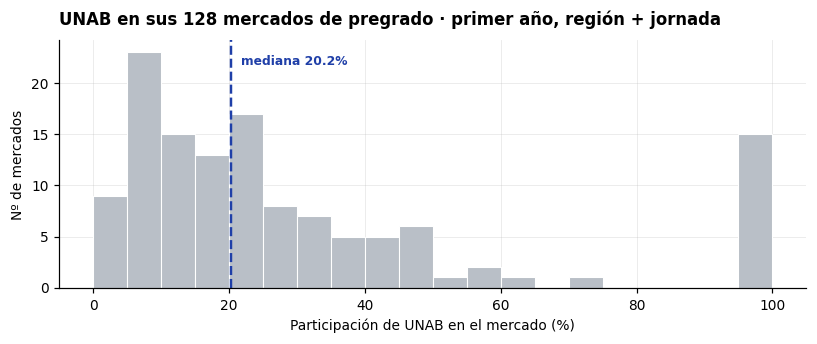

In [30]:
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.hist(unab.share, bins=np.arange(0, 105, 5), color=GRIS, edgecolor='white', linewidth=.7)
ax.axvline(unab.share.median(), color=FOCO, lw=1.6, ls='--')
ax.text(unab.share.median() + 1.5, ax.get_ylim()[1]*.9,
        f'mediana {unab.share.median():.1f}%', color=FOCO, fontsize=8, fontweight='bold')
ax.set_xlabel('Participación de UNAB en el mercado (%)')
ax.set_ylabel('Nº de mercados')
ax.set_title(f'UNAB en sus {len(unab)} mercados de pregrado · primer año, región + jornada',
             loc='left', fontweight='bold', pad=10)
plt.tight_layout(); plt.show()

In [31]:
grandes = unab.nlargest(10, 'val')[['area_generica','geo','jornada','val','total_mercado','share','pos','n_inst']]
grandes.round(1).reset_index(drop=True)

,area_generica,geo,jornada,val,total_mercado,share,pos,n_inst
0,Ingeniería Comercial,Metropolitana,Diurna,469.0,5265.0,8.9,3,22
1,Derecho,Metropolitana,Diurna,388.0,4039.0,9.6,2,24
2,Medicina Veterinaria,Metropolitana,Diurna,386.0,2029.0,19.0,2,9
3,Psicología,Metropolitana,Diurna,376.0,4243.0,8.9,2,25
4,Enfermería,Metropolitana,Diurna,354.0,3065.0,11.5,2,19
5,Kinesiología,Metropolitana,Diurna,347.0,2266.0,15.3,2,20
6,Ingeniería Civil Industrial,Metropolitana,Diurna,312.0,1859.0,16.8,1,17
7,Bachillerato y/o Licenciatura en Salud,Metropolitana,Diurna,298.0,666.0,44.7,1,3
8,Psicología,Valparaíso,Diurna,290.0,1084.0,26.8,1,9
9,Ingeniería Civil en Computación e Informática,Metropolitana,Diurna,278.0,1791.0,15.5,1,14


El patrón: UNAB queda bajo el 10% justamente en sus carreras más masivas de la Región
Metropolitana —Ingeniería Comercial, Derecho, Psicología— y domina donde el mercado es chico.
Volumen propio alto no es lo mismo que posición de mercado.

### 2.7 Por qué el ámbito geográfico es un selector y no una constante

El sitio deja elegir comuna, provincia, región o país. No es un adorno: la participación cambia
por completo según el denominador.

In [32]:
filas = []
for amb in ['comuna','provincia','region','pais']:
    m = construir_mercados(df, foco='UNIVERSIDAD ANDRES BELLO', ambito=amb)
    u = m[m.institucion == 'UNIVERSIDAD ANDRES BELLO']
    psi = u[u.area_generica == 'Psicología'].nlargest(1, 'val').iloc[0]
    filas.append({
        'ámbito': amb,
        'territorio': psi.geo,
        'UNAB': int(psi.val),
        'mercado': int(psi.total_mercado),
        'share_%': round(psi.share, 1),
        'competidores': int(psi.n_inst),
    })
pd.DataFrame(filas)

,ámbito,territorio,UNAB,mercado,share_%,competidores
0,comuna,LAS CONDES,376,688,54.7,3
1,provincia,SANTIAGO,376,4243,8.9,25
2,region,Metropolitana,376,4243,8.9,25
3,pais,PAÍS,828,9601,8.6,49


La misma carrera, la misma institución, el mismo año: **54,7% en Las Condes, 8,9% en la Región
Metropolitana.** Ambas cifras son correctas y responden preguntas distintas.

La relevante para admisión es la regional: un postulante de Maipú elige entre todo Santiago, no
entre las universidades de su comuna. La comunal solo sirve si existe una fricción real de
desplazamiento. Por eso el default del sitio es región.

Es el tipo de decisión que hay que declarar en cualquier informe, porque un lector que no la ve
puede quedarse con el número que le acomode.

### 2.8 Suite de chequeos

Todo junto, para correr de una sola vez cuando cambie la base o el código.

In [33]:
_ = suite(df)

                           chequeo  pasa
                    filas = 16,089  True
          matrícula = informe SIES  True
                 cod_carrera única  True
                sexo suma al total  True
                edad suma al total  True
                primer año ≤ total  True
sin ceros explícitos en primer año  True
 continuidad no reporta primer año  True
           mercados = app.js (128)  True
         lidera sola = app.js (25)  True
 liderazgo compartido = app.js (3)  True
     sin competencia = app.js (15)  True
 shares suman 100% en cada mercado  True

✓ TODO PASA


---

## Qué queda anotado

**Sobre la base**

- Corte único de 2025. No hay crecimiento medible sin bajar los archivos de años anteriores.
- El vacío en primer año no es cero. En Plan Regular de Continuidad es "no se pide el dato", y
  arrastra 65.693 matriculados, 33.298 de ellos online.
- La cobertura TES solo vale en primer año de pregrado.
- No binarios: 27 filas con dato. No desagregable.

**Sobre el sitio**

- Los cálculos de `app.js` coinciden con pandas en los 128 mercados y en el desglose de
  liderazgos. Dos implementaciones independientes, mismo resultado.
- **La validación pagó su costo tres veces.** Destapó (1) un desempate que dependía del orden de
  las filas del CSV, (2) que el "líder" de Ingeniería Comercial RM le gana al segundo por 3 alumnos
  en 5.265, y (3) que 15 de los 42 liderazgos eran mercados donde UNAB es la única oferente.
- El conteo defendible es **25 liderazgos limpios, 3 compartidos y 15 monopolios locales**, no 42.
- El umbral de 5% es una convención de materialidad declarada, no una prueba estadística. Queda
  como control en el tablero para que cualquiera lo mueva y vea el efecto.
- El ámbito geográfico cambia la participación de 54,7% a 8,9% para la misma carrera. Es la
  decisión de análisis más sensible de todo el tablero y por eso queda expuesta como control.

**Pendiente**

- Verificar desde qué año el SIES reporta `MODALIDAD`. Antes lo online venía como jornada
  "A Distancia". De eso depende hasta dónde estira la serie histórica.